In [3]:
import matplotlib.pyplot as plt
import h5py
import glob
import numpy as np
import ROOT
import matplotlib.colors as colors
from matplotlib.colors import LogNorm

In [64]:
path = "packet-0060154-2025_11_20_07_55_40_CST.FLOW.hdf5"
f = h5py.File(path, "r")
Num_track=len(f["analysis/rock_muon_tracks/data"])

In [5]:
def slice_from_ref_region(dset, ref_region_row):
    start = int(ref_region_row["start"])
    stop  = int(ref_region_row["stop"])
    return dset[start:stop]
def point_to_segment_distance(P, A, B):
    # P: (N,3) points; A,B: (3,) endpoints
    AB = B - A
    AP = P - A
    denom = np.dot(AB, AB)
    if denom == 0:
        return np.linalg.norm(P - A, axis=1)
    t = (AP @ AB) / denom
    t = np.clip(t, 0.0, 1.0)
    proj = A + t[:,None] * AB[None,:]
    return np.linalg.norm(P - proj, axis=1)
def get_event_hits_by_event_index(f, event_index):
    hits = f["charge/calib_prompt_hits/data"]
    rr   = f["charge/events/ref/charge/calib_prompt_hits/ref_region"]
    return slice_from_ref_region(hits, rr[event_index])
def find_event_index_from_event_id(f, event_id):
    ev = f["charge/events/data"]
    # common patterns: either event_id matches ev["id"], or it’s just an index
    if "id" in ev.dtype.names:
        m = np.where(ev["id"] == event_id)[0]
        if len(m): 
            return int(m[0])
    # fallback: if event_id looks like an index
    if 0 <= int(event_id) < len(ev):
        return int(event_id)
    raise ValueError("Couldn't map rock_muon_tracks.event_id to charge/events")    
def get_track_event_hits(f, track_index):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    ev_idx = find_event_index_from_event_id(f, tr["event_id"])
    return get_event_hits_by_event_index(f, ev_idx), ev_idx        

In [7]:
def obtain_muon_dqdx(f, track_index, r_dis=2.0, track_dx=2.0, qmin=0.0):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    all_hits, ev_idx = get_track_event_hits(f, track_index)

    if len(all_hits) == 0:
        return np.array([]),np.array([])

    A = np.array([tr["x_start"], tr["y_start"], tr["z_start"]], dtype=float)
    B = np.array([tr["x_end"], tr["y_end"], tr["z_end"]], dtype=float)
    P = np.vstack([all_hits["x"], all_hits["y"], all_hits["z"]]).T
    AB = B - A
    L  = np.linalg.norm(AB)
    u = AB / L
    s = (P - A) @ u  # along-track coordinate in cm, 0 at A
    
    Q = all_hits["Q"]
    d = point_to_segment_distance(P, A, B)
    goodQ = np.isfinite(Q) & (Q >= qmin)
    mask = goodQ & (d <= r_dis) & (s >= 0.0) & (s <= L)
   
    s_sel = s[mask]
    Q_sel = Q[mask]

   # sel_hits = all_hits[mask]

    win  = float(track_dx)
    step = win/2  

    s_centers = np.arange(0.5*win, L-0.5*win + 1e-9, step)
    dqdx = []
    cnt = []
    for sc in s_centers:
        sel = np.abs(s_sel - sc) <= 0.5*win
        Qsum = np.sum(Q_sel[sel])
        cnt.append(Q_sel[sel].size)
        dqdx.append(Qsum / win)

    dqdx = np.array(dqdx)
    #mask_nonzero = dqdx != 0
    cnt = np.array(cnt)
    s_centers = s_centers[cnt > 3]
    dqdx = dqdx[cnt>3]
    cnt=cnt[cnt>3]
    return L-s_centers,dqdx,cnt

In [8]:
MODULE_BOXES = [
    {"module": 0, "xmin":  3.07, "xmax": 63.93, "ymin": -61.85, "ymax": 61.85, "zmin":  2.68, "zmax": 64.32},
    {"module": 1, "xmin":  3.07, "xmax": 63.93, "ymin": -61.85, "ymax": 61.85, "zmin": -64.32, "zmax": -2.68},
    {"module": 2, "xmin": -63.93, "xmax": -3.07, "ymin": -61.85, "ymax": 61.85, "zmin":  2.68, "zmax": 64.32},
    {"module": 3, "xmin": -63.93, "xmax": -3.07, "ymin": -61.85, "ymax": 61.85, "zmin": -64.32, "zmax": -2.68},
]

In [9]:
def point_on_boundary_of_box(p, box, tol=1.0):

    x, y, z = map(float, p)

    # must be inside the box (allow tol slack), otherwise cannot be on its boundary
    if not (box["xmin"]-tol <= x <= box["xmax"]+tol and
            box["ymin"]-tol <= y <= box["ymax"]+tol and
            box["zmin"]-tol <= z <= box["zmax"]+tol):
        return set()

    faces = set()
    if abs(x - box["xmin"]) <= tol: faces.add("xmin")
    if abs(x - box["xmax"]) <= tol: faces.add("xmax")
    if abs(y - box["ymin"]) <= tol: faces.add("ymin")
    if abs(y - box["ymax"]) <= tol: faces.add("ymax")
    if abs(z - box["zmin"]) <= tol: faces.add("zmin")
    if abs(z - box["zmax"]) <= tol: faces.add("zmax")
    return faces

In [10]:
def endpoint_touches_boundary(p, tol=1.0):
    """
    Returns list of matches: [{"module": m, "faces": {...}}, ...]
    Empty list => not on any module boundary.
    """
    out = []
    for box in MODULE_BOXES:
        faces = point_on_boundary_of_box(p, box, tol=tol)
        if faces:
            out.append({"module": box["module"], "faces": faces})
    return out

def both_endpoints_on_boundary(p_start, p_end, tol=1.0):
    """
    Returns (ok, start_info, end_info)
    ok=True iff both endpoints touch at least one module boundary.
    """
    start_info = endpoint_touches_boundary(p_start, tol=tol)
    end_info   = endpoint_touches_boundary(p_end,   tol=tol)
    ok = (len(start_info) > 0) and (len(end_info) > 0)
    return ok

In [60]:
#track_index = 5
s=[]
dqdx=[]
for track_index in range(len(f["analysis/rock_muon_tracks/data"])):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    all_hits, ev_idx = get_track_event_hits(f, track_index)
    A = np.array([tr["x_start"], tr["y_start"], tr["z_start"]], dtype=float)
    B = np.array([tr["x_end"], tr["y_end"], tr["z_end"]], dtype=float)
    through = both_endpoints_on_boundary(A,B,tol=1.0)
    if (through):
        s_track,dqdx_track,cnt = obtain_muon_dqdx(f, track_index,r_dis=2.0, track_dx=1.5)
        s.append(s_track)
        dqdx.append(dqdx_track)

/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/3631703465.py:14: RuntimeWarning: divide by zero encountered in matmul
  s = (P - A) @ u  # along-track coordinate in cm, 0 at A
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/3631703465.py:14: RuntimeWarning: overflow encountered in matmul
  s = (P - A) @ u  # along-track coordinate in cm, 0 at A
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/3631703465.py:14: RuntimeWarning: invalid value encountered in matmul
  s = (P - A) @ u  # along-track coordinate in cm, 0 at A
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/1740198754.py:12: RuntimeWarning: divide by zero encountered in matmul
  t = (AP @ AB) / denom
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/1740198754.py:12: RuntimeWarning: overflow encountered in matmul
  t = (AP @ AB) / denom
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/1740198754.py:12: RuntimeWarning: invalid valu

In [12]:
s=[]
dqdx3=[]
dqdx1=[]
for track_index in range(len(f["analysis/rock_muon_tracks/data"])):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    all_hits, ev_idx = get_track_event_hits(f, track_index)
    A = np.array([tr["x_start"], tr["y_start"], tr["z_start"]], dtype=float)
    B = np.array([tr["x_end"], tr["y_end"], tr["z_end"]], dtype=float)
    through = both_endpoints_on_boundary(A,B,tol=1.0)
    if (through):
        s_track,dqdx_3,cnt = obtain_muon_dqdx(f, track_index,r_dis=3.0, track_dx=2.0)
        s_track,dqdx_1,cnt = obtain_muon_dqdx(f, track_index,r_dis=1.0, track_dx=2.0)
        #s.append(s_track)
        dqdx1.append(dqdx_1)
        dqdx3.append(dqdx_3)

/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/3631703465.py:14: RuntimeWarning: divide by zero encountered in matmul
  s = (P - A) @ u  # along-track coordinate in cm, 0 at A
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/3631703465.py:14: RuntimeWarning: overflow encountered in matmul
  s = (P - A) @ u  # along-track coordinate in cm, 0 at A
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/3631703465.py:14: RuntimeWarning: invalid value encountered in matmul
  s = (P - A) @ u  # along-track coordinate in cm, 0 at A
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/1740198754.py:12: RuntimeWarning: divide by zero encountered in matmul
  t = (AP @ AB) / denom
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/1740198754.py:12: RuntimeWarning: overflow encountered in matmul
  t = (AP @ AB) / denom
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/1740198754.py:12: RuntimeWarning: invalid valu

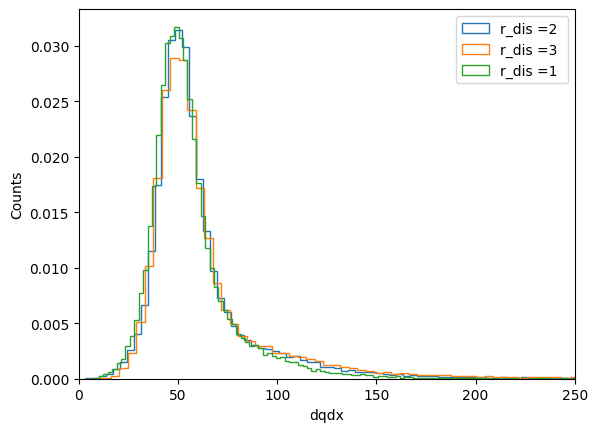

In [13]:
fig, ax = plt.subplots()
bins=200
ax.hist(np.concatenate(dqdx), bins=bins, histtype="step",density=True, label="r_dis =2 ")
ax.hist(np.concatenate(dqdx3), bins=bins, histtype="step",density=True, label="r_dis =3 ")
ax.hist(np.concatenate(dqdx1), bins=bins, histtype="step",density=True, label="r_dis =1 ")

ax.set_xlabel("dqdx")
ax.set_ylabel("Counts")
ax.legend()
ax.set_xlim(0,250)
plt.show()

In [11]:
s=[]
#dqdxt3=[]
dqdxt10=[]
for track_index in range(len(f["analysis/rock_muon_tracks/data"])):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    all_hits, ev_idx = get_track_event_hits(f, track_index)
    A = np.array([tr["x_start"], tr["y_start"], tr["z_start"]], dtype=float)
    B = np.array([tr["x_end"], tr["y_end"], tr["z_end"]], dtype=float)
    through = both_endpoints_on_boundary(A,B,tol=1.0)
    if (through):
 #       s_track,dqdx_t3,cnt = obtain_muon_dqdx(f, track_index,r_dis=2.0, track_dx=3.0)
        s_track,dqdx_t10,cnt = obtain_muon_dqdx(f, track_index,r_dis=2.0, track_dx=10.0)
        #s.append(s_track)
        dqdxt10.append(dqdx_t10)
        #dqdxt3.append(dqdx_t3)

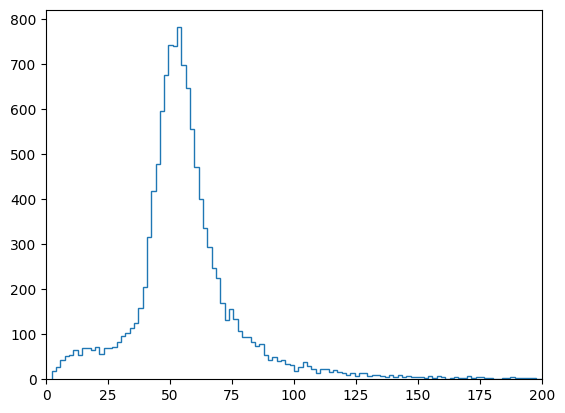

In [12]:
plt.hist(np.concatenate(dqdxt10), bins=bins,histtype="step")
plt.xlim(0,200)
plt.show()

In [13]:
s=[]
#dqdxt3=[]
dqdx=[]
for track_index in range(len(f["analysis/rock_muon_tracks/data"])):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    all_hits, ev_idx = get_track_event_hits(f, track_index)
    A = np.array([tr["x_start"], tr["y_start"], tr["z_start"]], dtype=float)
    B = np.array([tr["x_end"], tr["y_end"], tr["z_end"]], dtype=float)
    through = both_endpoints_on_boundary(A,B,tol=1.0)
    if (through):
 #       s_track,dqdx_t3,cnt = obtain_muon_dqdx(f, track_index,r_dis=2.0, track_dx=3.0)
        s_track,dqdx_track,cnt = obtain_muon_dqdx(f, track_index,r_dis=2.0, track_dx=2.5)
        s.append(s_track)
        dqdx.append(dqdx_track)

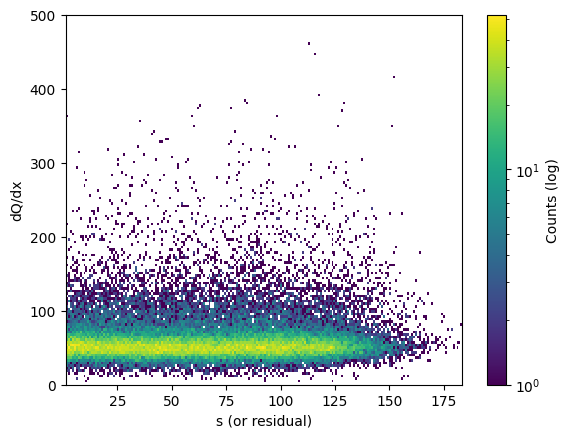

In [16]:
x = np.concatenate(s)
y = np.concatenate(dqdx)

plt.hist2d(
    x, y,
    bins=200,
    cmap="viridis",
    norm=colors.LogNorm()
)
plt.ylim(0, 500) 
plt.xlabel("s (or residual)")
plt.ylabel("dQ/dx")
plt.colorbar(label="Counts (log)")
plt.show()

In [76]:
import ROOT
import numpy as np

def _langaus_func(x, par):
    # par[0]=Landau width, par[1]=MPV, par[2]=Area, par[3]=Gaus sigma
    invsq2pi = 0.3989422804014
    mpshift  = -0.22278298

    xx    = x[0]
    width = par[0]
    mpv   = par[1]
    area  = par[2]
    gs    = par[3]

    # numeric convolution settings
    np_steps = 120
    sc = 5.0

    xlow = xx - sc*gs
    xupp = xx + sc*gs
    step = (xupp - xlow)/np_steps

    s = 0.0
    for i in range(np_steps):
        xval = xlow + (i+0.5)*step
        land = ROOT.TMath.Landau(xval, mpv + mpshift*width, width) / width
        gaus = ROOT.TMath.Gaus(xx, xval, gs, True)   # True => normalized
        s += land * gaus

    return area * step * s


def mip_langaus_fit_root(
    data,
    nbins=250, x_min=0, x_max=250,
    fit_min=30, fit_max=80,
    rebin=2, quiet=True
):
    data = np.asarray(data).ravel()
    data = data[np.isfinite(data)]
    data = data[(data >= x_min) & (data <= x_max)]
    if data.size < 200:
        raise ValueError("Not enough finite data")

    uid = ROOT.TUUID().AsString()
    hname = f"h_dqdx_{uid}"
    cname = f"c_{uid}"
    fname = f"f_langaus_{uid}"

    h = ROOT.TH1F(hname, "MIP dE/dx;dE/dx;Counts", nbins, x_min, x_max)
    for v in data:
        h.Fill(float(v))
    if rebin and rebin > 1:
        h.Rebin(int(rebin))

    # peak for init
    peak_bin = h.GetMaximumBin()
    peak = h.GetXaxis().GetBinCenter(peak_bin)

    f = ROOT.TF1(fname, _langaus_func, fit_min, fit_max, 4)
    f.SetParNames("Lwidth", "MPV", "Area", "Gsigma")

    f.SetParameters(0.20, peak, h.Integral("width"), 0.20)

# Landau width: 放宽
    f.SetParLimits(0, 0.02*peak, 0.50*peak)

# MPV: 不要给 0.6~1.4 这么宽泛但又绑 peak 的方式；用更“窄但围绕 peak”的窗口
    f.SetParLimits(1, peak - 0.5, peak + 0.5)

# Gsigma: 放宽，避免卡死
    f.SetParLimits(3, 0.02*peak, 0.50*peak)
    opt = "RL"  # R range, L likelihood
    opt += "S"
    if quiet:
        opt += "Q"

    fitres = h.Fit(f, opt)

    mpv = float(f.GetParameter(1))
    mpv_err = float(f.GetParError(1))

    c = ROOT.TCanvas(cname, "Langaus fit", 900, 650)
    h.SetLineColor(ROOT.kBlue+1)
    h.Draw("hist")
    f.SetLineColor(ROOT.kRed)
    f.Draw("same")

    line = ROOT.TLine(mpv, 0, mpv, h.GetMaximum()*1.05)
    line.SetLineColor(ROOT.kRed)
    line.SetLineStyle(2)
    line.Draw("same")

    t = ROOT.TLatex()
    t.SetNDC(True)
    t.SetTextSize(0.035)
    t.DrawLatex(0.55, 0.85, f"MPV = {mpv:.2f} #pm {mpv_err:.2f}")
    t.DrawLatex(0.55, 0.80, f"Fit range: [{fit_min:.1f}, {fit_max:.1f}]")

    c.Update()
    c.Draw()

    return mpv, mpv_err, h, f, c, fitres

In [61]:
data = np.concatenate(dqdx)
mpv, mpv_err, h, f, c, fitres = mip_langaus_fit_root(
    data,
    fit_min=32.5, fit_max=80, 
    rebin=2
)
print("MPV =", mpv, "+/-", mpv_err)

MPV = 48.22140690921655 +/- 0.05800121371501632


In [111]:
s=[]
dqdx=[]
f = h5py.File(path, "r")
for track_index in range(Num_track):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    all_hits, ev_idx = get_track_event_hits(f, track_index)
    A = np.array([tr["x_start"], tr["y_start"], tr["z_start"]], dtype=float)
    B = np.array([tr["x_end"], tr["y_end"], tr["z_end"]], dtype=float)
    through = both_endpoints_on_boundary(A,B,tol=1.0)
    if (through):
        s_track,dqdx_track,cnt = obtain_muon_dqdx(f, track_index,r_dis=2., track_dx=1.5)
        s.append(s_track)
        dqdx.append(dqdx_track)
data = np.concatenate(dqdx)
mpv, mpv_err, h, f, c, fitres = mip_langaus_fit_root(
    data,
    fit_min=32.5, fit_max=80, 
    rebin=2
)
print("MPV =", mpv, "+/-", mpv_err)        

/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/3631703465.py:14: RuntimeWarning: divide by zero encountered in matmul
  s = (P - A) @ u  # along-track coordinate in cm, 0 at A
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/3631703465.py:14: RuntimeWarning: overflow encountered in matmul
  s = (P - A) @ u  # along-track coordinate in cm, 0 at A
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/3631703465.py:14: RuntimeWarning: invalid value encountered in matmul
  s = (P - A) @ u  # along-track coordinate in cm, 0 at A
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/1740198754.py:12: RuntimeWarning: divide by zero encountered in matmul
  t = (AP @ AB) / denom
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/1740198754.py:12: RuntimeWarning: overflow encountered in matmul
  t = (AP @ AB) / denom
/var/folders/b7/hfs601n14z7fx8h9n2sgdf1c0000gn/T/ipykernel_73821/1740198754.py:12: RuntimeWarning: invalid valu

MPV = 48.22140690921655 +/- 0.05800121371501632


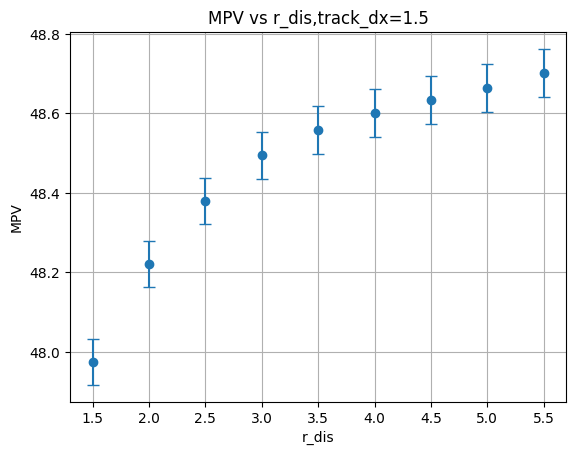

In [95]:
r_dis=[1.5,2,2.5,3,3.5,4,4.5,5,5.5]
MPV=[ 47.97461050498496,48.22140690921655,48.379549390856766,48.49453077802342,48.55817410066671,48.60098787977456,48.63264474893807,48.66475601181221,48.70133297827401  ]
MPV_err=[0.057757708705654665,0.05800121371501632,0.05844486042039421,0.059081805789816144,0.05939145021786274,0.05987081527403504,0.06029388046245998,0.0606504656814586,0.061149388315008935]
plt.figure()

plt.errorbar(
    r_dis,
    MPV,
    yerr=MPV_err,
    fmt='o',
    capsize=4
)

plt.xlabel("r_dis")
plt.ylabel("MPV")
plt.title("MPV vs r_dis,track_dx=1.5")

plt.grid(True)
plt.show()

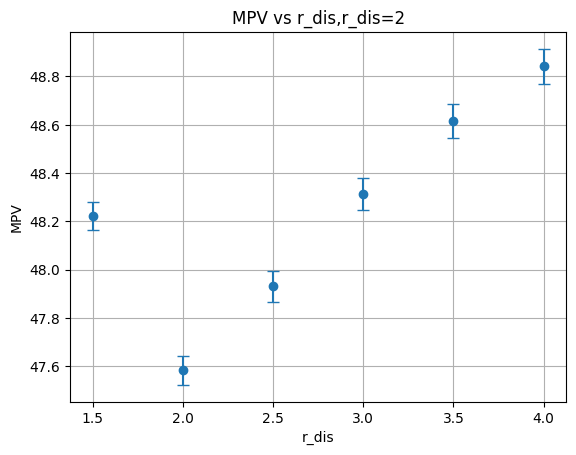

In [94]:
track_dx=[1.5,2,2.5,3,3.5,4]
MPV=[ 48.22140690921655,  47.58334542489194,47.93035240848664,48.31397202837169 ,48.61677565775458 ,48.84084762095413 ]
MPV_err=[0.05800121371501632,0.05995074473148421,0.06362759398107443,0.06638044329865167,0.07020038903677417,0.07328495627595899]
plt.figure()

plt.errorbar(
    track_dx,
    MPV,
    yerr=MPV_err,
    fmt='o',
    capsize=4
)

plt.xlabel("r_dis")
plt.ylabel("MPV")
plt.title("MPV vs r_dis,r_dis=2")

plt.grid(True)
plt.show()

In [29]:
#f_MC = ROOT.TFile.Open("/Volumes/HC/geant4/MCP_efficiency.root")
f_MC = ROOT.TFile.Open("/Users/hongc/Geant4/NewPhysicsAt2x2/build/Mu_dis.root")
df = ROOT.RDataFrame("PixelEDep", f_MC)
df_cut = df.Filter("EnergyDep > 0.1")
energy_array = df_cut.AsNumpy(["EnergyDep"])["EnergyDep"]
print(type(energy_array))

<class 'ROOT._pythonization._rdf_utils.ndarray'>


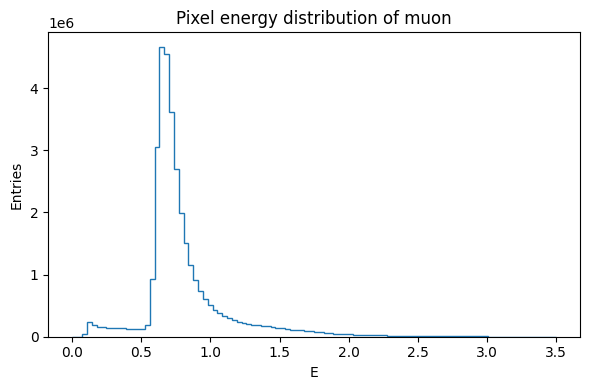

In [30]:
plt.figure(figsize=(6,4))

plt.hist(
    energy_array,
    bins=100,
    range=(0, 3.5),
    histtype="step"
)
#plt.yscale("log")

plt.xlabel("E")
plt.ylabel("Entries")
plt.title("Pixel energy distribution of muon")
plt.tight_layout()
plt.show()

In [106]:
qmin=0
f_data = h5py.File(path, "r")
q_data=[]
for track_index in range(Num_track):
    tr = f_data["analysis/rock_muon_tracks/data"][track_index]
    all_hits, ev_idx = get_track_event_hits(f_data, track_index)
    Q = all_hits["Q"]
    goodQ = np.isfinite(Q) & (Q >= qmin)
    hits = all_hits[goodQ]
    q_data.append(hits)

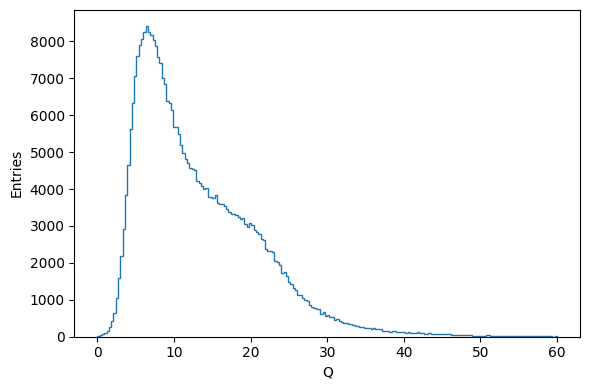

In [107]:
plt.figure(figsize=(6,4))

plt.hist(
    np.concatenate(q_data)["Q"],
    bins=200,
    range=(0, 60),
    histtype="step"
)
#plt.yscale("log")

plt.xlabel("Q")
plt.ylabel("Entries")
plt.tight_layout()
plt.show()

In [108]:
counts_data, edges = np.histogram(np.concatenate(q_data)["Q"], bins=200, range=(0, 100))
counts_MC, edges =np.histogram(energy_array*(48.22/2.1),bins=200,range=(0, 100))
N_spills = 258000
N_off_used = 19127
w = N_spills / N_off_used 
counts_scaled_data = counts_data * w
scale = 4.5e8/3e6
counts_scaled_MC = counts_MC * scale
centers = 0.5 * (edges[1:] + edges[:-1])

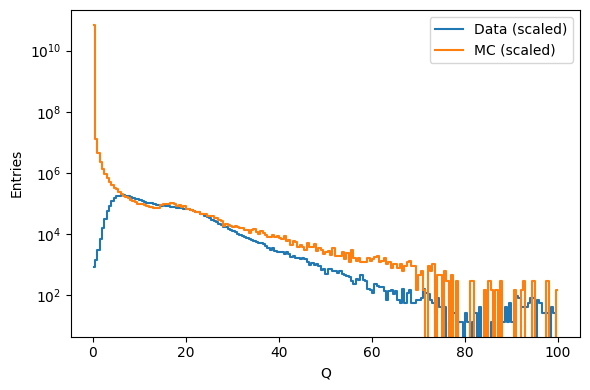

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.step(
    centers,
    counts_scaled_data,
    where="mid",
    label="Data (scaled)"
)

plt.step(
    centers,
    counts_scaled_MC,
    where="mid",
    label="MC (scaled)"
)
plt.yscale("log")
plt.xlabel("Q")
plt.ylabel("Entries")
plt.legend()
plt.tight_layout()
plt.show()

In [80]:
import ROOT, numpy as np
import pandas as pd

r_dis = 2.0
track_dx = 1.772
x0, y0, z0 = 35.0, 0.0, -75.0
R2 = r_dis*r_dis

f_MC = ROOT.TFile.Open("/Users/hongc/Geant4/NewPhysicsAt2x2/build/Mu_dis.root")
df = ROOT.RDataFrame("PixelEDep", f_MC)

cols = ["EventID", "EnergyDep", "EnergyDep_Primary", "x", "y", "z"]

cut = (
    f"EnergyDep > 0.1"
    f" && ((x-{x0})*(x-{x0}) + (y-{y0})*(y-{y0}) < {R2})"
)

pdf = pd.DataFrame(df.Filter(cut).AsNumpy(cols))
pdf["slice"] = np.floor((pdf["z"] - z0) / track_dx).astype(np.int32)

# --- estimate z pitch from data (robust) ---
z_unique = np.sort(pdf["z"].unique())
dz = np.diff(z_unique)
pitch = np.median(dz[dz > 1e-6])   # cm
print("estimated z pitch (cm):", pitch)

g = pdf.groupby(["EventID","slice"])

E_tot  = g["EnergyDep"].sum()
E_prim = g["EnergyDep_Primary"].sum()
zmin   = g["z"].min()
zmax   = g["z"].max()

# only keep slices where muon primary exists
mask_mu = (E_prim > 0.1)

# use per-slice effective length instead of fixed dx
L = (zmax - zmin + pitch)

dEdx_prim_mu = (E_prim[mask_mu] / L[mask_mu])
dEdx_tot_mu  = (E_tot[mask_mu]  / L[mask_mu])

print(dEdx_prim_mu.head())
print("N slices total:", len(dEdx_prim_mu))
print(dEdx_prim_mu.describe())

estimated z pitch (cm): 4.055764382115967e-05
EventID  slice
0        6        2.582325
         7        3.321060
         8        2.379166
         9        3.379840
         10       2.815068
dtype: float64
N slices total: 4813496
count    4.813496e+06
mean     4.201903e+02
std      3.105733e+03
min      8.277100e-02
25%      2.307580e+00
50%      2.519393e+00
75%      2.910963e+00
max      2.132804e+05
dtype: float64


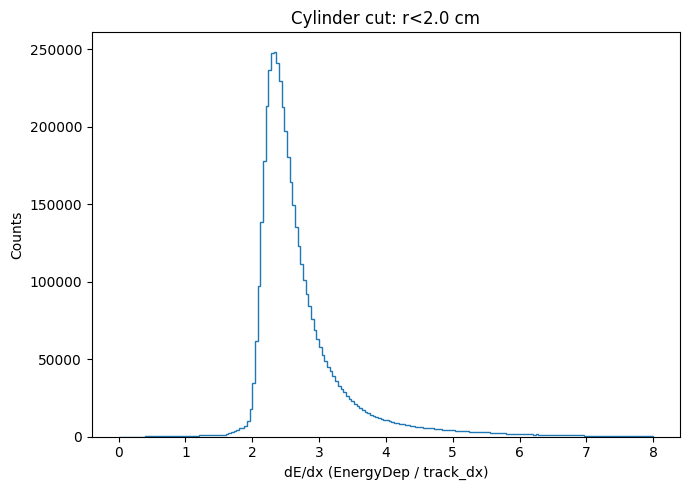

In [46]:
vals = dEdx_prim_mu.values

plt.figure(figsize=(7,5))
plt.hist(vals, bins=200,range=(0,8),histtype="step")
#plt.xlim(0,10)
plt.xlabel("dE/dx (EnergyDep / track_dx)")
plt.ylabel("Counts")
plt.title(f"Cylinder cut: r<{r_dis} cm")
plt.tight_layout()
plt.show()

In [81]:
mpv, mpv_err, h, f, c, fitres = mip_langaus_fit_root(
    dEdx_tot_mu.values,
    nbins=240,
    x_min=0.0,
    x_max=8.0,
    fit_min=1.95,
    fit_max=4.1,
    rebin=1,
    quiet=False
)

****************************************
Minimizer is Minuit2 / Migrad
MinFCN                    =      381.399
Chi2                      =      762.797
NDf                       =           61
Edm                       =   1.2452e-08
NCalls                    =          143
Lwidth                    =     0.132746   +/-   0.000130609  	 (limited)
MPV                       =       2.3718   +/-   0.000157105  	 (limited)
Area                      =       154415   +/-   76.2802     
Gsigma                    =    0.0615979   +/-   0.000357562  	 (limited)


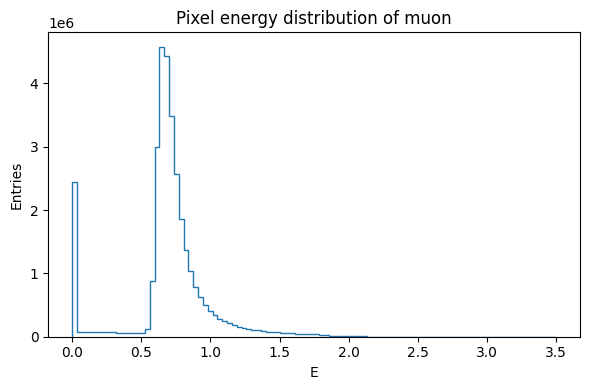

In [18]:
energy_pri = df_cut.AsNumpy(["EnergyDep_Primary_only"])["EnergyDep_Primary_only"]
plt.figure(figsize=(6,4))

plt.hist(
    energy_pri,
    bins=100,
    range=(0, 3.5),
    histtype="step"
)
#plt.yscale("log")

plt.xlabel("E")
plt.ylabel("Entries")
plt.title("Pixel energy distribution of muon")
plt.tight_layout()
plt.show()